In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import math

from pyro_cases.utils.vae_dict import vae_dict
from pyro_cases.utils.run_non_amoretized_vae import train_and_test_non_amortized_vae

In [3]:
device = torch.device("cuda:1")

In [4]:
out_dict = train_and_test_non_amortized_vae(task_name="two_moons",
                                            seed=126,
                                            device=device,
                                            lr=1e-3,
                                            num_particles=1,
                                            vectorize_particles=False,
                                            steps=10_000,
                                            test_seed=7272,
                                            num_test_obs=1000,
                                            show_progress=True,
                                            return_vae=True,
                                            suppress_error=False)

100%|██████████| 10000/10000 [01:46<00:00, 93.98it/s]

[task two_moons seed 126 completes] task start time: Sun Jul 27 11:38:10 2025; task end time: Sun Jul 27 11:39:56 2025; cost time: 106.4 seconds


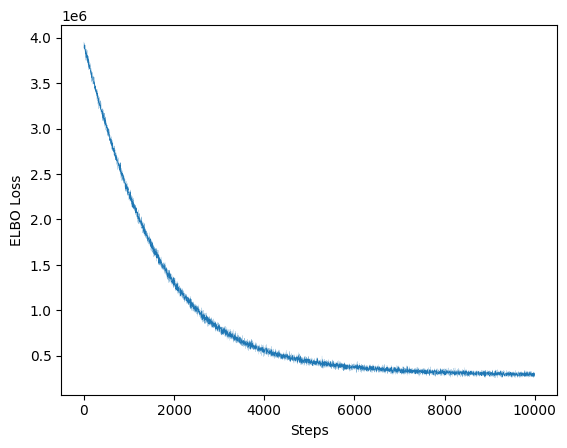

In [5]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.show()

### VSBC

In [6]:
elbo_vsbc = out_dict["elbo_vsbc"]

In [7]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

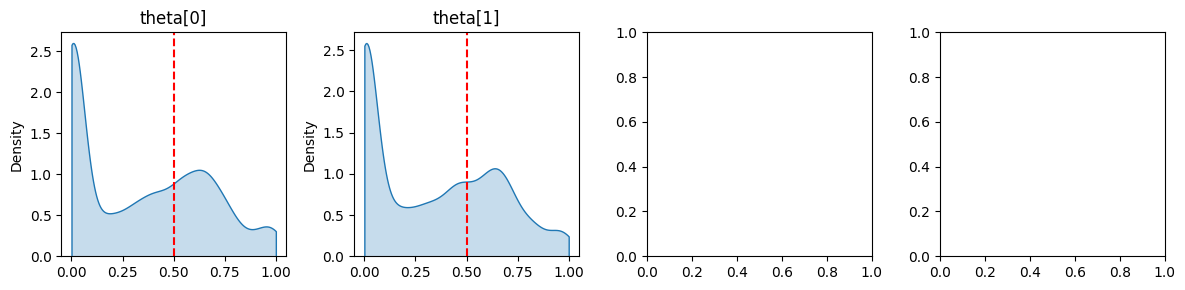

In [8]:
plot_vsbc(elbo_vsbc)

### Output

In [9]:
out_dict.keys()

dict_keys(['seed', 'task', 'elbo_training_loss', 'elbo_test_sample_dict', 'elbo_test_result_dict', 'elbo_vae', 'elbo_vsbc', 'elbo_error'])

In [10]:
out_dict["elbo_test_result_dict"].keys()

dict_keys(['obs_seed', 'obs', 'est_theta1', 'est_theta2', 'raw_pred', 'true_theta'])

In [13]:
out_dict["elbo_test_result_dict"]["obs"].shape

torch.Size([1000, 2])

In [14]:
out_dict["elbo_test_result_dict"]["obs"][:5]

tensor([[-0.1448,  0.0593],
        [-0.2639,  0.6632],
        [-0.7512, -0.0938],
        [-0.2346, -0.3977],
        [ 0.3403,  1.0328]])

In [15]:
out_dict["elbo_test_result_dict"]["true_theta"][:5]

tensor([[ 0.3350,  0.3363],
        [-0.7987,  0.0276],
        [ 0.8305,  0.7369],
        [ 0.7123,  0.0844],
        [-0.6915,  0.7293]])

In [16]:
out_dict["elbo_test_result_dict"]["est_theta1"][:5]

tensor([[ 2.1958,  4.8940],
        [ 3.6663,  7.7536],
        [ 6.1428,  8.4107],
        [11.9404,  5.6544],
        [ 6.7595, 11.4672]])

In [17]:
out_dict["elbo_test_result_dict"]["est_theta2"][:5]

tensor([[ 3.1917,  5.9712],
        [37.5559,  6.5621],
        [28.2080, 65.0357],
        [13.5396, 23.8911],
        [32.8666,  4.7961]])

In [18]:
def two_moon_posterior(x: torch.Tensor, theta: torch.Tensor):
    assert x.ndim == 1 and x.shape[0] == 2
    assert theta.ndim == 2 and theta.shape[1] == 2
    r_cos_alpha = x[0] + theta.sum(dim=-1).abs() / math.sqrt(2) - 0.25
    r_sin_alpha = x[1] + (theta[:, 0] - theta[:, 1]) / math.sqrt(2)
    r = (r_cos_alpha ** 2 + r_sin_alpha ** 2).sqrt()
    post_log_prob = torch.distributions.Normal(torch.ones_like(r) * 0.1, torch.ones_like(r) * 0.01).log_prob(r)
    return torch.where(r_cos_alpha < 0.0, -torch.inf, post_log_prob)

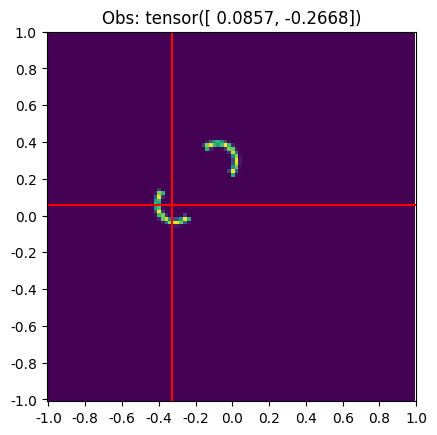

In [29]:
test_i = 152
theta_mesh = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 100),
                                        torch.linspace(-1, 1, 100),
                                        indexing="ij"), dim=-1).view(-1, 2)  # (100 x 100, 2)
obs = out_dict["elbo_test_result_dict"]["obs"][test_i]
theta_log_prob = two_moon_posterior(obs, theta_mesh)
theta_prob = torch.exp(theta_log_prob).view(100, 100)

pred_alpha = out_dict["elbo_test_result_dict"]["est_theta1"][test_i]
pred_beta = out_dict["elbo_test_result_dict"]["est_theta2"][test_i]
pred_mean = (pred_alpha  / (pred_alpha + pred_beta)) * 2 - 1

plt.imshow(theta_prob, origin="lower")
plt.xticks(range(0, 101, 10), [f"{(i / 50 - 1):.1f}" for i in range(0, 101, 10)])
plt.yticks(range(0, 101, 10), [f"{(i / 50 - 1):.1f}" for i in range(0, 101, 10)])
plt.axvline(x=(pred_mean[1] + 1) / 2 * 100, color="red")
plt.axhline(y=(pred_mean[0] + 1) / 2 * 100, color="red")
plt.title(f"Obs: {obs}")
plt.show()

### Smoke Test

In [ ]:
for i, task_name in enumerate(vae_dict.keys()):
    print(f"[{i}] run task {task_name}")
    try:
        out_dict = train_and_test_non_amortized_vae(task_name=task_name,
                                                    seed=123456,
                                                    device=device,
                                                    lr=1e-3,
                                                    num_particles=1,
                                                    vectorize_particles=False,
                                                    steps=10,
                                                    test_seed=7272,
                                                    num_test_obs=1000,
                                                    show_progress=False,
                                                    silent=False,
                                                    return_vae=True,
                                                    suppress_error=False)
    except ValueError:
        print(f"[{i}] task {task_name} value error")
    else:
        print(f"[{i}] task {task_name} passes")
    print()